## Setup and preprocessing — FFF, fresh raw load

In [2]:
# Block 1 — Setup, imports, output folder, raw load, encoding, imd_band fix

import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

print(df_sel.shape)
print(df_sel.columns.tolist())

(7762, 55)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'ass_10_date', 'ass_10_score', 'ass_11_date', 'ass_11_score', 'ass_12_date', 'ass_12_score', 'clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_subpage', 'clicks_url']


## Assessment binning, click variation check

In [5]:
# Block 2 — Assessment NaN->-1 + quartile bin, click variation check

assessment_cols = [f'ass_{i}_score' for i in range(1, 13)]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

print("Assessment bin counts:")
for col in assessment_cols:
    print(col, df_sel[col].nunique(), "bins")

click_cols_all = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
                   'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
                   'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
                   'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource',
                   'clicks_subpage', 'clicks_url']
for col in click_cols_all:
    df_sel[col] = df_sel[col].fillna(0)

print("\nClick variation:")
for col in click_cols_all:
    nonzero = (df_sel[col] > 0).sum()
    unique_vals = df_sel[col].nunique()
    print(col, "nonzero:", nonzero, f"({round(nonzero/len(df_sel)*100,1)}%)", "| unique vals:", unique_vals)

Assessment bin counts:
ass_1_score 4 bins
ass_2_score 3 bins
ass_3_score 3 bins
ass_4_score 3 bins
ass_5_score 2 bins
ass_6_score 3 bins
ass_7_score 3 bins
ass_8_score 3 bins
ass_9_score 3 bins
ass_10_score 3 bins
ass_11_score 3 bins
ass_12_score 3 bins

Click variation:
clicks_dataplus nonzero: 2326 (30.0%) | unique vals: 91
clicks_dualpane nonzero: 2648 (34.1%) | unique vals: 41
clicks_folder nonzero: 1934 (24.9%) | unique vals: 14
clicks_forumng nonzero: 6741 (86.8%) | unique vals: 1263
clicks_glossary nonzero: 701 (9.0%) | unique vals: 59
clicks_homepage nonzero: 7084 (91.3%) | unique vals: 1223
clicks_htmlactivity nonzero: 1918 (24.7%) | unique vals: 26
clicks_oucollaborate nonzero: 3172 (40.9%) | unique vals: 72
clicks_oucontent nonzero: 6946 (89.5%) | unique vals: 2481
clicks_ouelluminate nonzero: 1211 (15.6%) | unique vals: 109
clicks_ouwiki nonzero: 5423 (69.9%) | unique vals: 208
clicks_page nonzero: 6251 (80.5%) | unique vals: 65
clicks_questionnaire nonzero: 3792 (48.9%) | 

## total_clicks composite — sum raw clicks (excluding clicks_repeatactivity), quartile-bin, drop individual columns

In [8]:
# Block 3 — total_clicks composite, clicks_repeatactivity excluded

click_cols = [c for c in click_cols_all if c != 'clicks_repeatactivity']

df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel['total_clicks'] = pd.qcut(df_sel['total_clicks'], q=4, labels=False, duplicates='drop')

print(df_sel['total_clicks'].nunique(), "bins")
print(df_sel['total_clicks'].value_counts().sort_index())

df_sel_combined = df_sel.drop(columns=click_cols_all)
print(df_sel_combined.shape)

4 bins
total_clicks
0    1942
1    1940
2    1939
3    1941
Name: count, dtype: int64
(7762, 38)


## Final modeling variable set — drop identifiers and date columns

In [11]:
# Block 4 — Build df_model

date_cols = [c for c in df_sel_combined.columns if c.endswith('_date')] + ['date_registration', 'date_unregistration']
id_cols = ['code_presentation', 'id_student']

df_model = df_sel_combined.drop(columns=date_cols + id_cols)

print(df_model.shape)
print(df_model.columns.tolist())
print(df_model.dtypes)

(7762, 22)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score', 'total_clicks']
gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
num_of_prev_attempts    int64
studied_credits         int64
disability              int64
final_result            int64
ass_1_score             int64
ass_2_score             int64
ass_3_score             int64
ass_4_score             int64
ass_5_score             int64
ass_6_score             int64
ass_7_score             int64
ass_8_score             int64
ass_9_score             int64
ass_10_score            int64
ass_11_score            int64
ass_12_score            int64
total_clicks         

## Build FFF combined DAG in networkx, derive treatments and adjustment sets

In [16]:
# Block 5 — Build DiGraph, derive treatments and adjustment sets

edges = [
    ('gender', 'studied_credits'),
    ('gender', 'total_clicks'),
    ('highest_education', 'region'),
    ('imd_band', 'region'),
    ('imd_band', 'ass_1_score'),
    ('imd_band', 'highest_education'),
    ('age_band', 'highest_education'),
    ('highest_education', 'disability'),
    ('imd_band', 'disability'),
    ('age_band', 'total_clicks'),
    ('num_of_prev_attempts', 'studied_credits'),
    ('region', 'ass_1_score'),
    ('ass_1_score', 'ass_2_score'),
    ('ass_1_score', 'ass_3_score'),
    ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'final_result'),
    ('total_clicks', 'ass_1_score'),
    ('ass_2_score', 'ass_3_score'),
    ('ass_2_score', 'ass_4_score'),
    ('ass_2_score', 'ass_5_score'),
    ('ass_2_score', 'ass_6_score'),
    ('ass_2_score', 'ass_8_score'),
    ('ass_2_score', 'final_result'),
    ('total_clicks', 'ass_2_score'),
    ('ass_3_score', 'ass_4_score'),
    ('ass_3_score', 'ass_5_score'),
    ('ass_3_score', 'ass_6_score'),
    ('ass_3_score', 'ass_7_score'),
    ('ass_3_score', 'ass_8_score'),
    ('ass_3_score', 'ass_9_score'),
    ('ass_3_score', 'final_result'),
    ('total_clicks', 'ass_3_score'),
    ('ass_4_score', 'ass_5_score'),
    ('ass_4_score', 'ass_7_score'),
    ('ass_4_score', 'ass_8_score'),
    ('ass_4_score', 'ass_9_score'),
    ('ass_4_score', 'ass_10_score'),
    ('ass_4_score', 'ass_11_score'),
    ('ass_4_score', 'ass_12_score'),
    ('ass_4_score', 'final_result'),
    ('total_clicks', 'ass_4_score'),
    ('ass_5_score', 'ass_10_score'),
    ('ass_5_score', 'final_result'),
    ('total_clicks', 'ass_5_score'),
    ('ass_6_score', 'ass_7_score'),
    ('ass_6_score', 'ass_8_score'),
    ('ass_6_score', 'ass_9_score'),
    ('ass_6_score', 'ass_10_score'),
    ('ass_6_score', 'ass_11_score'),
    ('ass_6_score', 'ass_12_score'),
    ('total_clicks', 'ass_6_score'),
    ('ass_7_score', 'ass_8_score'),
    ('ass_7_score', 'ass_9_score'),
    ('ass_7_score', 'ass_10_score'),
    ('ass_7_score', 'ass_11_score'),
    ('ass_7_score', 'ass_12_score'),
    ('ass_7_score', 'final_result'),
    ('total_clicks', 'ass_7_score'),
    ('ass_8_score', 'ass_9_score'),
    ('ass_8_score', 'ass_10_score'),
    ('ass_8_score', 'ass_11_score'),
    ('ass_8_score', 'ass_12_score'),
    ('ass_8_score', 'final_result'),
    ('total_clicks', 'ass_8_score'),
    ('ass_9_score', 'ass_10_score'),
    ('ass_9_score', 'ass_11_score'),
    ('ass_9_score', 'ass_12_score'),
    ('ass_9_score', 'final_result'),
    ('total_clicks', 'ass_9_score'),
    ('ass_10_score', 'ass_11_score'),
    ('ass_10_score', 'ass_12_score'),
    ('ass_10_score', 'final_result'),
    ('total_clicks', 'ass_10_score'),
    ('ass_11_score', 'ass_12_score'),
    ('ass_11_score', 'final_result'),
    ('ass_12_score', 'final_result'),
    ('total_clicks', 'ass_12_score'),
    ('total_clicks', 'final_result'),
]
undirected_pairs = [('region', 'disability')]

G = nx.DiGraph()
G.add_edges_from(edges)

treatments = [n for n in G.nodes() if n != 'final_result' and nx.has_path(G, n, 'final_result')]
print("Treatments:", treatments)
print("\nCount:", len(treatments))

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments: ['gender', 'total_clicks', 'highest_education', 'region', 'imd_band', 'ass_1_score', 'age_band', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_8_score', 'ass_7_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score']

Count: 18
gender -> []
total_clicks -> ['gender', 'age_band']
highest_education -> ['imd_band', 'age_band']
region -> ['highest_education', 'imd_band']
imd_band -> []
ass_1_score -> ['imd_band', 'region', 'total_clicks']
age_band -> []
ass_2_score -> ['ass_1_score', 'total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'total_clicks']
ass_5_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score', 'total_clicks']
ass_6_score -> ['ass_2_score', 'ass_3_score', 'total_clicks']
ass_8_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score', 'total_clicks']
ass_7_score -> ['ass_3_score', 'ass_4_score', 'ass_6_s

## Correction — rebuild DAG without erroneous imd_band->ass_1_score edge

In [19]:
# Block 5 (corrected) — Remove erroneous edge, rebuild

edges = [e for e in edges if e != ('imd_band', 'ass_1_score')]

G = nx.DiGraph()
G.add_edges_from(edges)

treatments = [n for n in G.nodes() if n != 'final_result' and nx.has_path(G, n, 'final_result')]
print("Treatments:", treatments)
print("\nCount:", len(treatments))

adjustment_sets = {t: list(G.predecessors(t)) for t in treatments}
for t, adj in adjustment_sets.items():
    print(t, "->", adj)

Treatments: ['gender', 'total_clicks', 'highest_education', 'region', 'imd_band', 'age_band', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_8_score', 'ass_7_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score']

Count: 18
gender -> []
total_clicks -> ['gender', 'age_band']
highest_education -> ['imd_band', 'age_band']
region -> ['highest_education', 'imd_band']
imd_band -> []
age_band -> []
ass_1_score -> ['region', 'total_clicks']
ass_2_score -> ['ass_1_score', 'total_clicks']
ass_3_score -> ['ass_1_score', 'ass_2_score', 'total_clicks']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'total_clicks']
ass_5_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score', 'total_clicks']
ass_6_score -> ['ass_2_score', 'ass_3_score', 'total_clicks']
ass_8_score -> ['ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_6_score', 'ass_7_score', 'total_clicks']
ass_7_score -> ['ass_3_score', 'ass_4_score', 'ass_6_score', 'tota

## DoWhy ATE loop — all 18 treatments, with 95% confidence intervals

In [22]:
# Block 6 — DoWhy ATE loop

results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    results.append({
        'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

results_df = pd.DataFrame(results)
results_df

gender: ATE=-0.011, CI=[-0.068, 0.046], significant=False
total_clicks: ATE=0.672, CI=[0.659, 0.685], significant=True
highest_education: ATE=0.209, CI=[0.179, 0.238], significant=True
region: ATE=-0.001, CI=[-0.007, 0.005], significant=False
imd_band: ATE=0.045, CI=[0.037, 0.053], significant=True
age_band: ATE=0.098, CI=[0.049, 0.147], significant=True
ass_1_score: ATE=0.152, CI=[0.137, 0.167], significant=True
ass_2_score: ATE=0.231, CI=[0.207, 0.255], significant=True
ass_3_score: ATE=0.462, CI=[0.438, 0.487], significant=True
ass_4_score: ATE=0.479, CI=[0.453, 0.506], significant=True
ass_5_score: ATE=0.194, CI=[0.155, 0.232], significant=True
ass_6_score: ATE=0.152, CI=[0.131, 0.174], significant=True
ass_8_score: ATE=0.283, CI=[0.255, 0.310], significant=True
ass_7_score: ATE=0.164, CI=[0.139, 0.188], significant=True
ass_9_score: ATE=0.261, CI=[0.233, 0.289], significant=True
ass_10_score: ATE=0.258, CI=[0.228, 0.287], significant=True
ass_11_score: ATE=0.358, CI=[0.326, 0.390]

,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,gender,[],-0.011367,-0.068371,0.045636,False
1,total_clicks,"[gender, age_band]",0.671566,0.658510,0.684622,True
2,highest_education,"[imd_band, age_band]",0.208815,0.179207,0.238422,True
3,region,"[highest_education, imd_band]",-0.000666,-0.006587,0.005255,False
4,imd_band,[],0.045072,0.037259,0.052884,True
5,age_band,[],0.097597,0.048601,0.146594,True
6,ass_1_score,"[region, total_clicks]",0.151945,0.136737,0.167152,True
7,ass_2_score,"[ass_1_score, total_clicks]",0.230850,0.207194,0.254506,True
8,ass_3_score,"[ass_1_score, ass_2_score, total_clicks]",0.462168,0.437727,0.486608,True
9,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score, total_...",0.479329,0.452908,0.505749,True


## Refutation — placebo treatment + random common cause, all 18 treatments

In [25]:
# Block 7 — Refutation loop

refutation_results = []

for treatment in treatments:
    common_causes = adjustment_sets[treatment]

    model = CausalModel(
        data=df_model,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    original_ate = estimate.value

    placebo_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute"
    )
    random_cause_refute = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )

    refutation_results.append({
        'treatment': treatment, 'original_ATE': original_ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_new_effect': random_cause_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - original_ate)
    })

    print(f"{treatment}: placebo_effect={placebo_refute.new_effect:.4f}, random_cause_effect={random_cause_refute.new_effect:.4f}")

refutation_df = pd.DataFrame(refutation_results)
refutation_df

gender: placebo_effect=0.0035, random_cause_effect=-0.0113
total_clicks: placebo_effect=-0.0006, random_cause_effect=0.6715
highest_education: placebo_effect=-0.0028, random_cause_effect=0.2088
region: placebo_effect=0.0000, random_cause_effect=-0.0007
imd_band: placebo_effect=0.0008, random_cause_effect=0.0451
age_band: placebo_effect=-0.0009, random_cause_effect=0.0976
ass_1_score: placebo_effect=0.0006, random_cause_effect=0.1519
ass_2_score: placebo_effect=-0.0005, random_cause_effect=0.2309
ass_3_score: placebo_effect=-0.0006, random_cause_effect=0.4622
ass_4_score: placebo_effect=0.0016, random_cause_effect=0.4793
ass_5_score: placebo_effect=-0.0010, random_cause_effect=0.1938
ass_6_score: placebo_effect=-0.0005, random_cause_effect=0.1523
ass_8_score: placebo_effect=0.0001, random_cause_effect=0.2825
ass_7_score: placebo_effect=-0.0008, random_cause_effect=0.1639
ass_9_score: placebo_effect=-0.0003, random_cause_effect=0.2613
ass_10_score: placebo_effect=0.0009, random_cause_eff

,treatment,original_ATE,placebo_new_effect,random_cause_new_effect,random_cause_diff
0,gender,-0.011367,0.003506,-0.011315,5.261473e-05
1,total_clicks,0.671566,-0.000637,0.671546,2.001227e-05
2,highest_education,0.208815,-0.002835,0.208840,2.564249e-05
3,region,-0.000666,0.000033,-0.000663,2.971206e-06
4,imd_band,0.045072,0.000764,0.045059,1.269119e-05
5,age_band,0.097597,-0.000929,0.097579,1.814556e-05
6,ass_1_score,0.151945,0.000642,0.151936,9.080059e-06
7,ass_2_score,0.230850,-0.000469,0.230860,1.075827e-05
8,ass_3_score,0.462168,-0.000642,0.462174,6.340750e-06
9,ass_4_score,0.479329,0.001555,0.479313,1.595651e-05


## EconML CausalForestDML — CATE setup, age_band vs imd_band moderators

In [28]:
# Block 8 — CATE loop, all 18 treatments x 2 moderators

cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

cate_df = pd.DataFrame(cate_results)
cate_df

gender | moderator=age_band: mean=-0.004, std=0.010
gender | moderator=imd_band: mean=-0.035, std=0.089
total_clicks | moderator=age_band: mean=0.669, std=0.005
total_clicks | moderator=imd_band: mean=0.662, std=0.033
highest_education | moderator=age_band: mean=0.212, std=0.033
highest_education | moderator=imd_band: mean=0.207, std=0.044
region | moderator=age_band: mean=-0.001, std=0.003
region | moderator=imd_band: mean=0.001, std=0.009
imd_band | moderator=age_band: mean=0.045, std=0.010
age_band | moderator=imd_band: mean=0.076, std=0.127
ass_1_score | moderator=age_band: mean=0.162, std=0.012
ass_1_score | moderator=imd_band: mean=0.152, std=0.031
ass_2_score | moderator=age_band: mean=0.218, std=0.022
ass_2_score | moderator=imd_band: mean=0.205, std=0.056
ass_3_score | moderator=age_band: mean=0.449, std=0.023
ass_3_score | moderator=imd_band: mean=0.457, std=0.048
ass_4_score | moderator=age_band: mean=0.484, std=0.028
ass_4_score | moderator=imd_band: mean=0.489, std=0.051
a

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,gender,age_band,[],-0.004371,-0.010263,0.012410,0.009943
1,gender,imd_band,[],-0.034806,-0.171108,0.114842,0.089097
2,total_clicks,age_band,[gender],0.668903,0.659768,0.672110,0.005413
3,total_clicks,imd_band,"[gender, age_band]",0.661587,0.593187,0.722370,0.032547
4,highest_education,age_band,[imd_band],0.211673,0.155349,0.231448,0.033373
5,highest_education,imd_band,[age_band],0.207285,0.136663,0.286539,0.043608
6,region,age_band,"[highest_education, imd_band]",-0.000598,-0.006494,0.001472,0.003494
7,region,imd_band,[highest_education],0.000701,-0.015400,0.017404,0.008928
8,imd_band,age_band,[],0.044582,0.038904,0.060753,0.009582
9,age_band,imd_band,[],0.075532,-0.143136,0.311060,0.126525


## CATE point + 95% CI plots by moderator bin — looped, saved per treatment

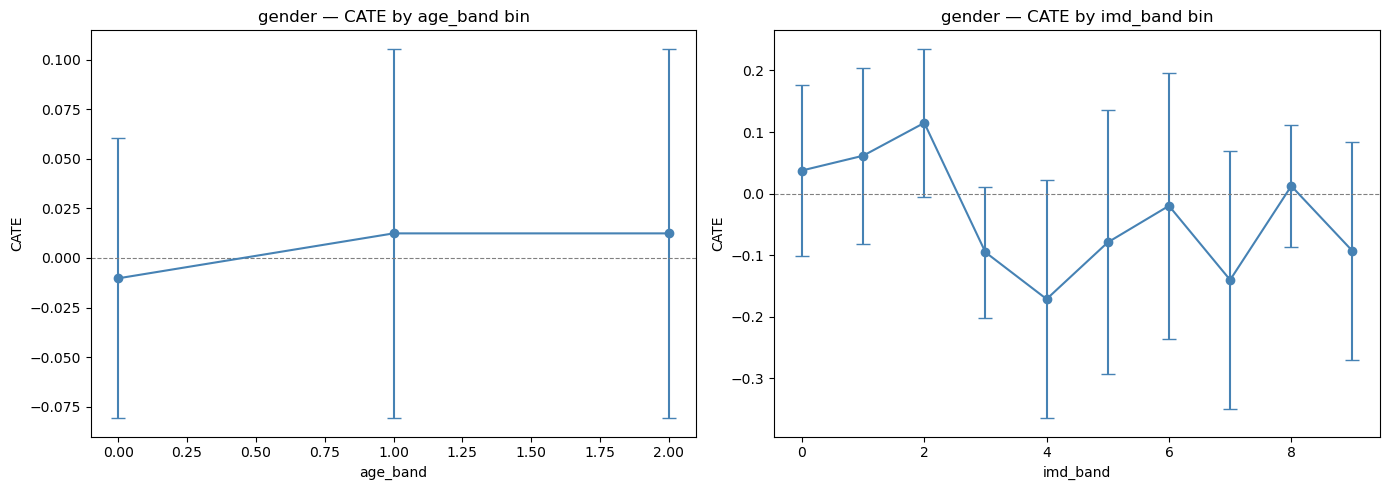

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_gender.png


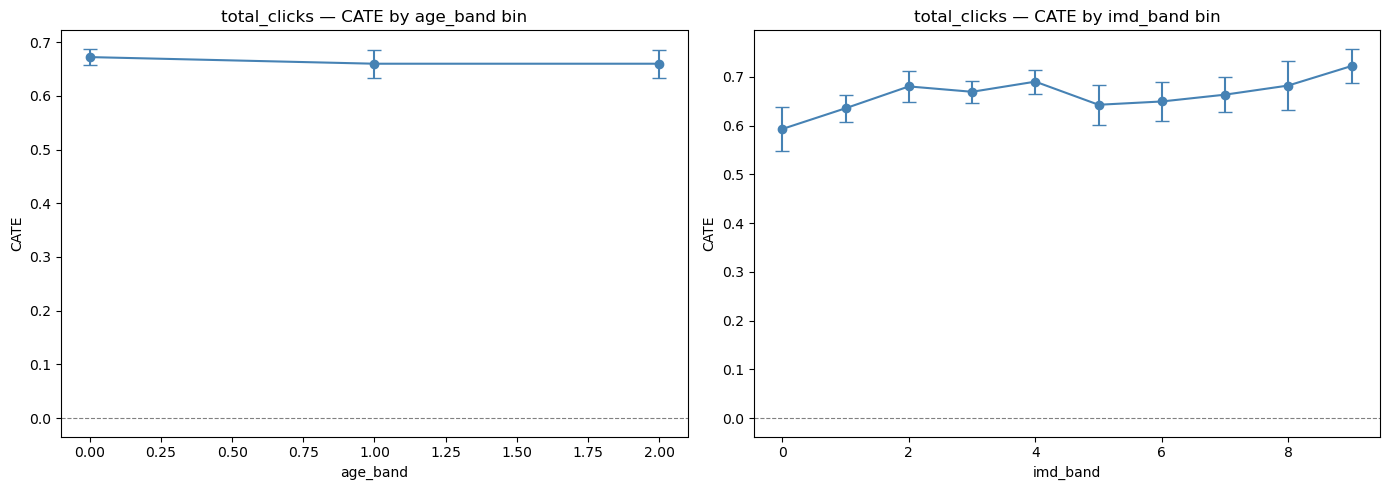

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_total_clicks.png


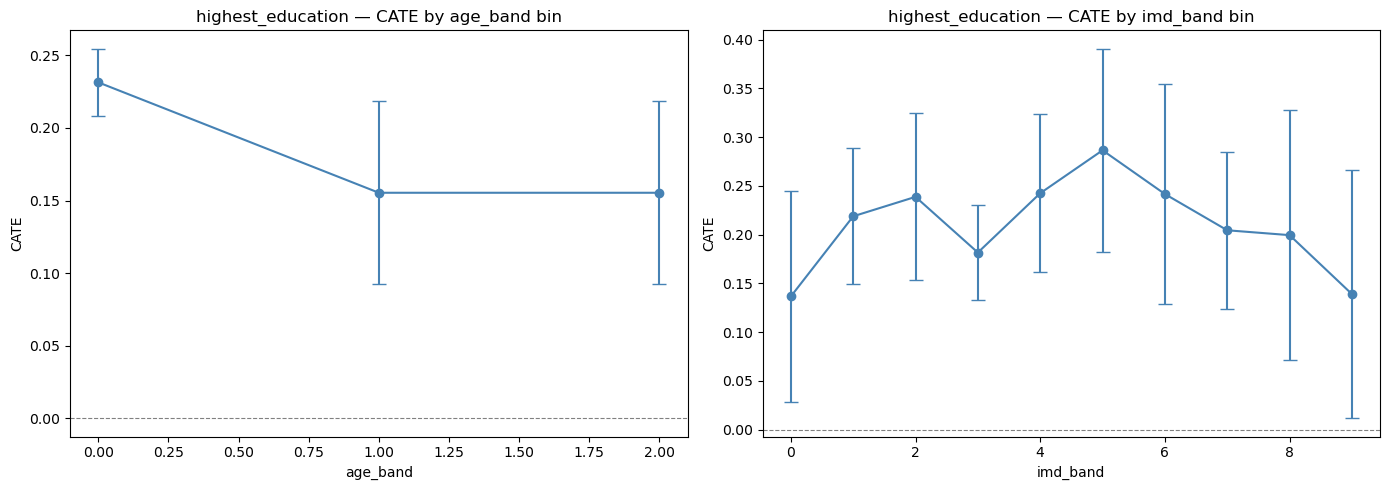

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_highest_education.png


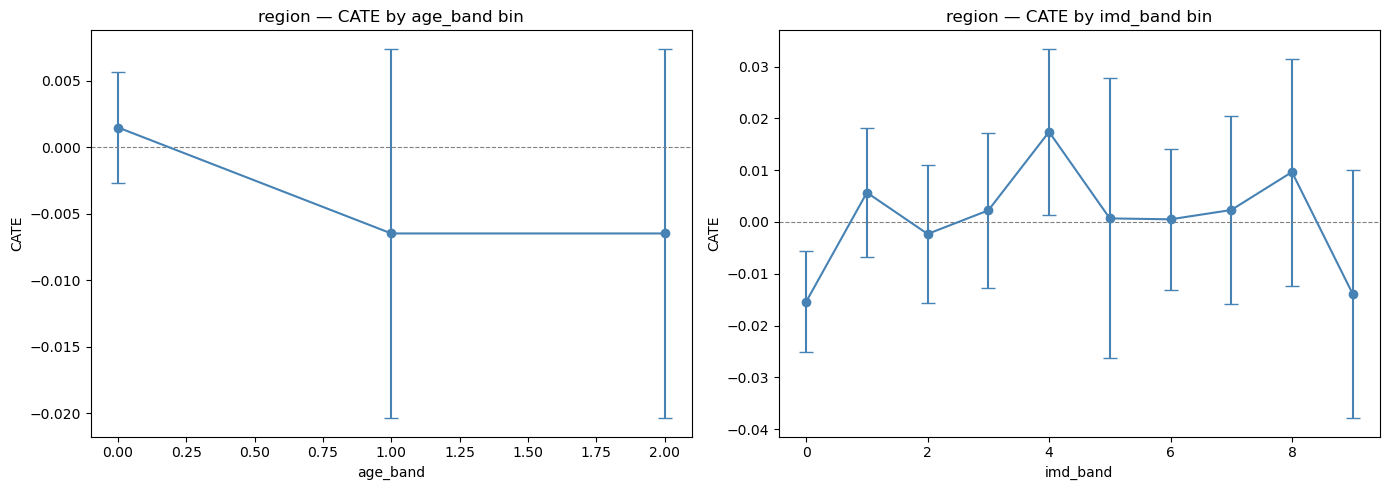

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_region.png


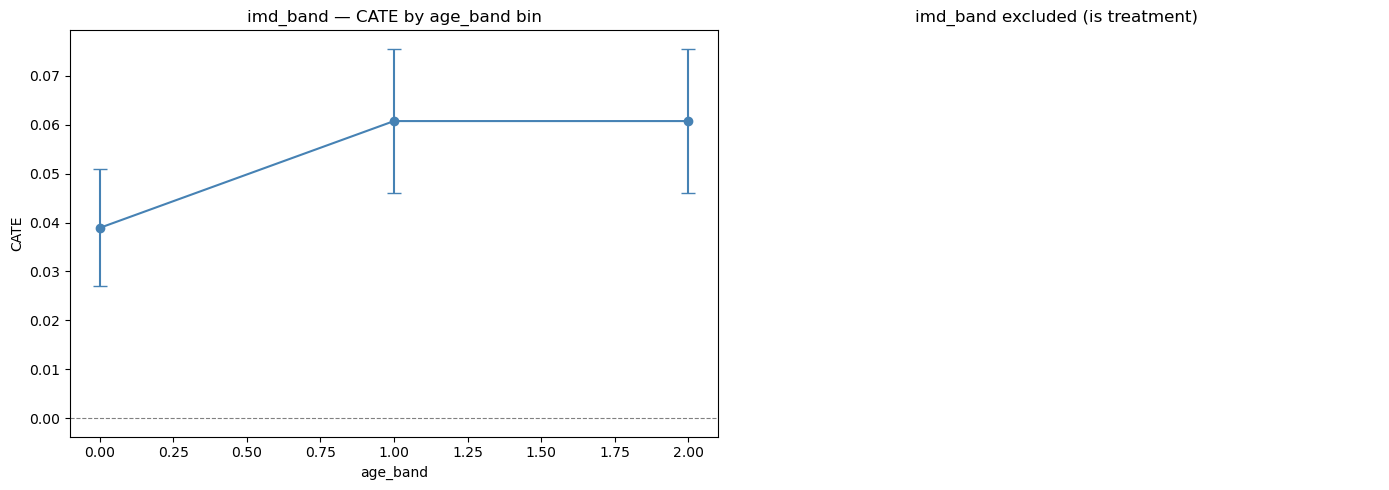

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_imd_band.png


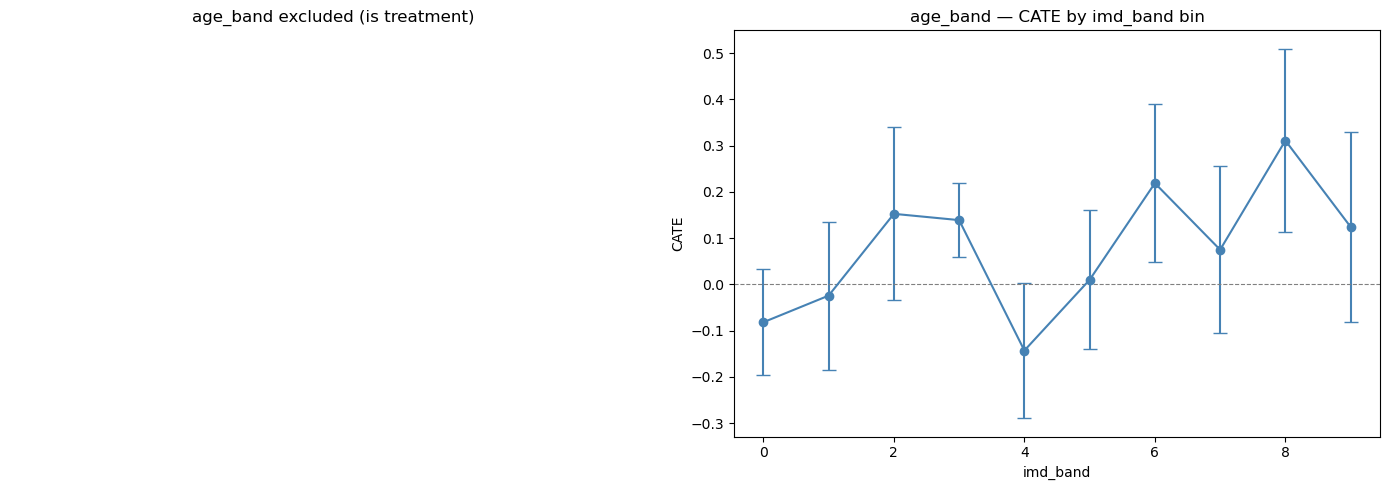

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_age_band.png


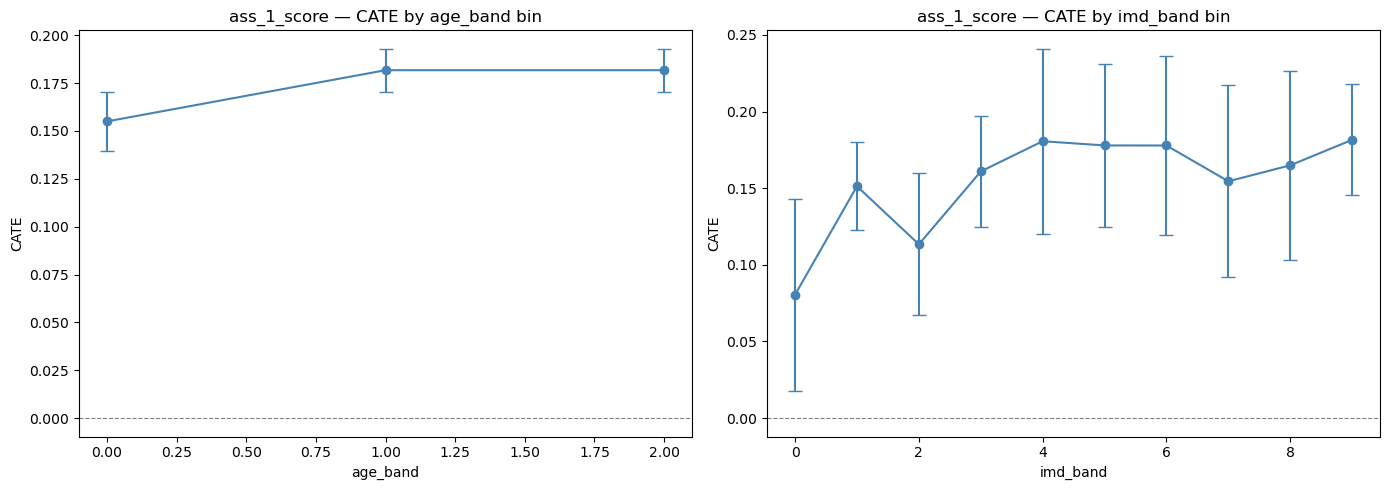

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_1_score.png


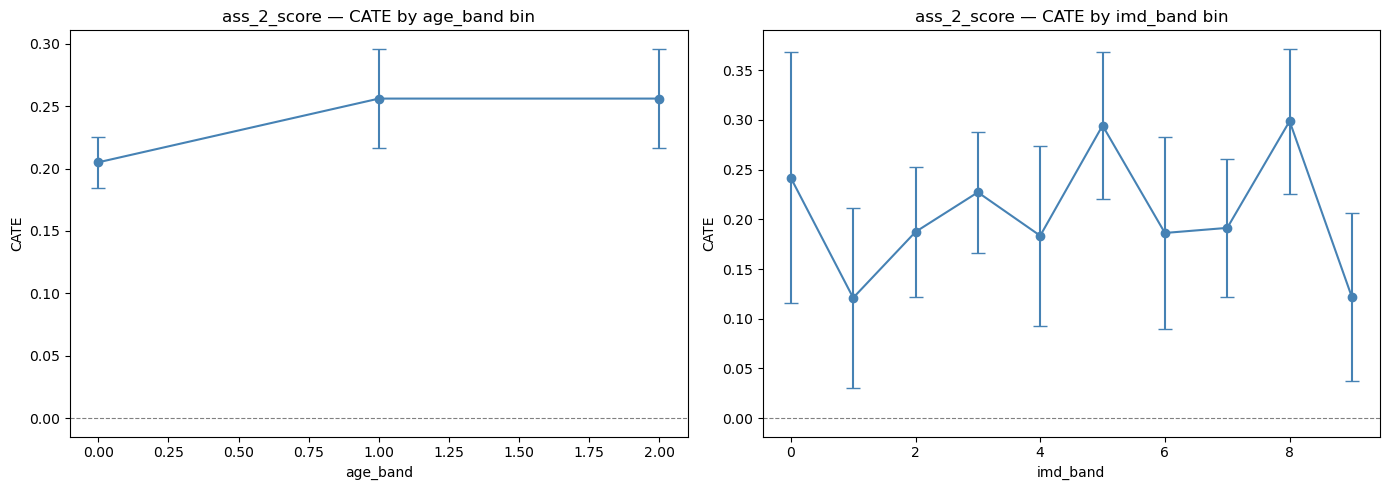

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_2_score.png


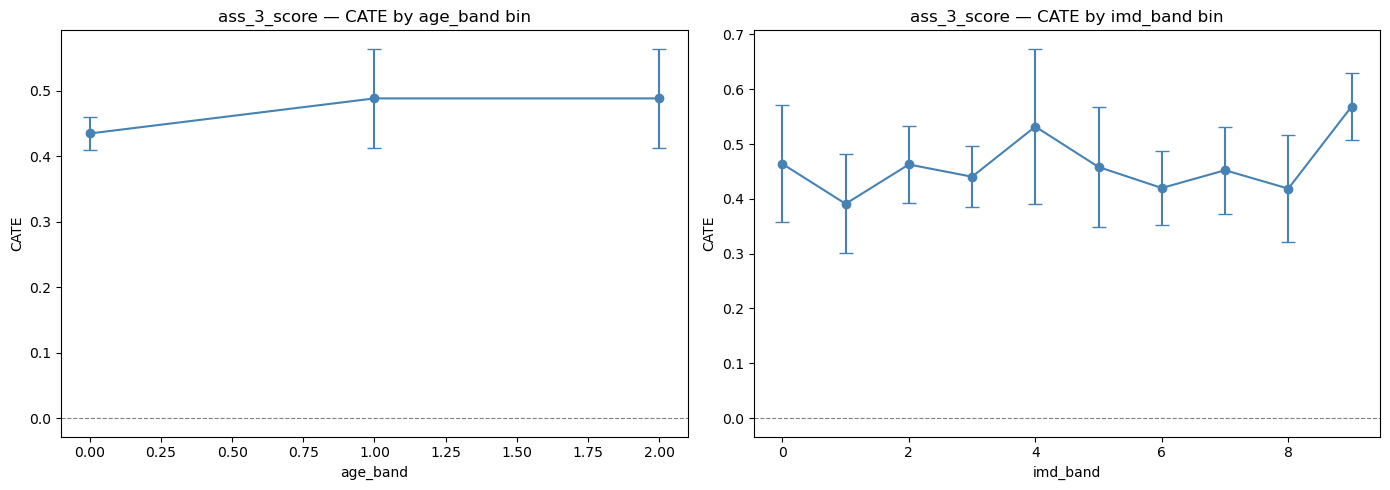

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_3_score.png


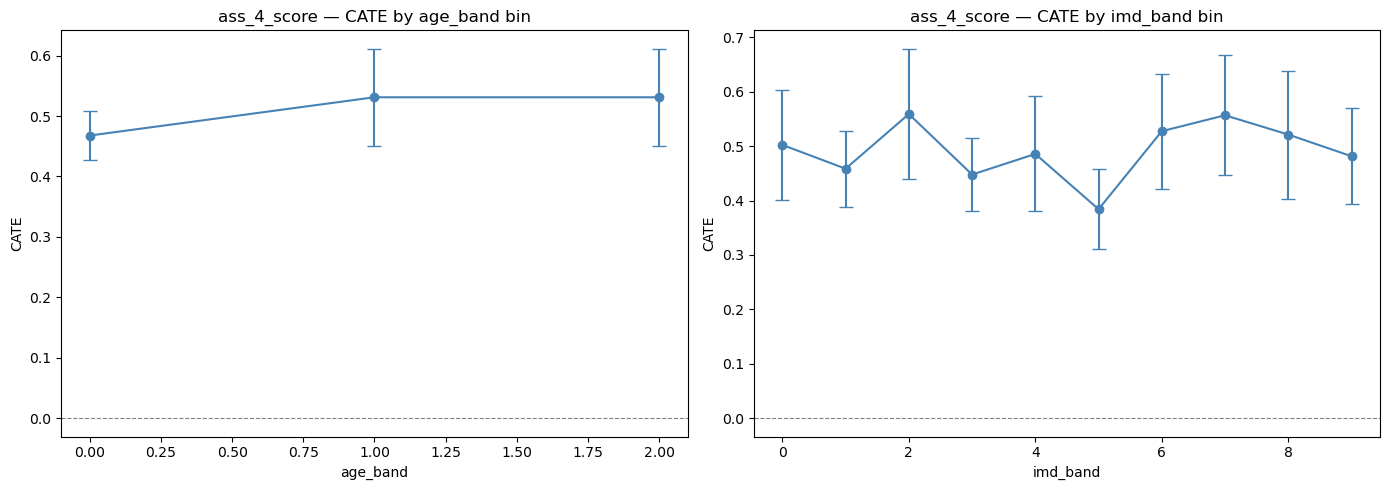

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_4_score.png


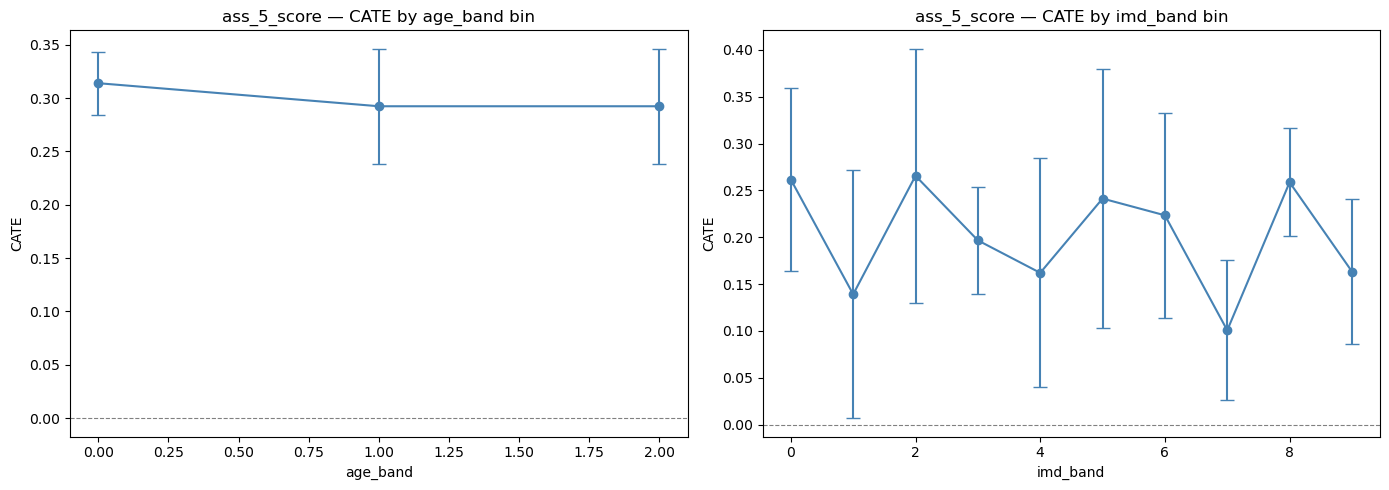

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_5_score.png


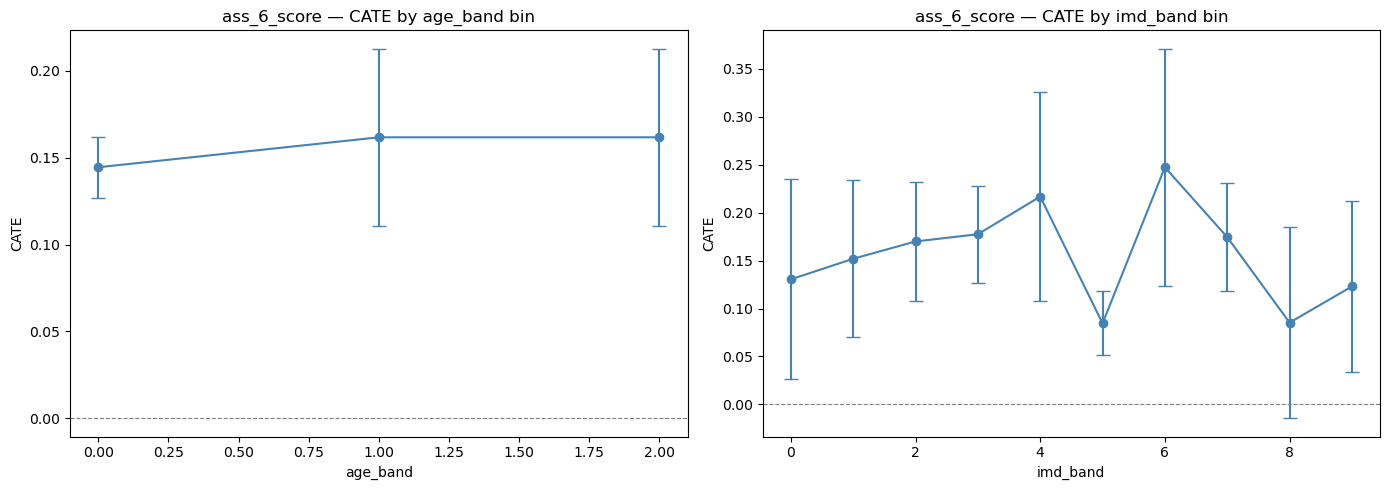

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_6_score.png


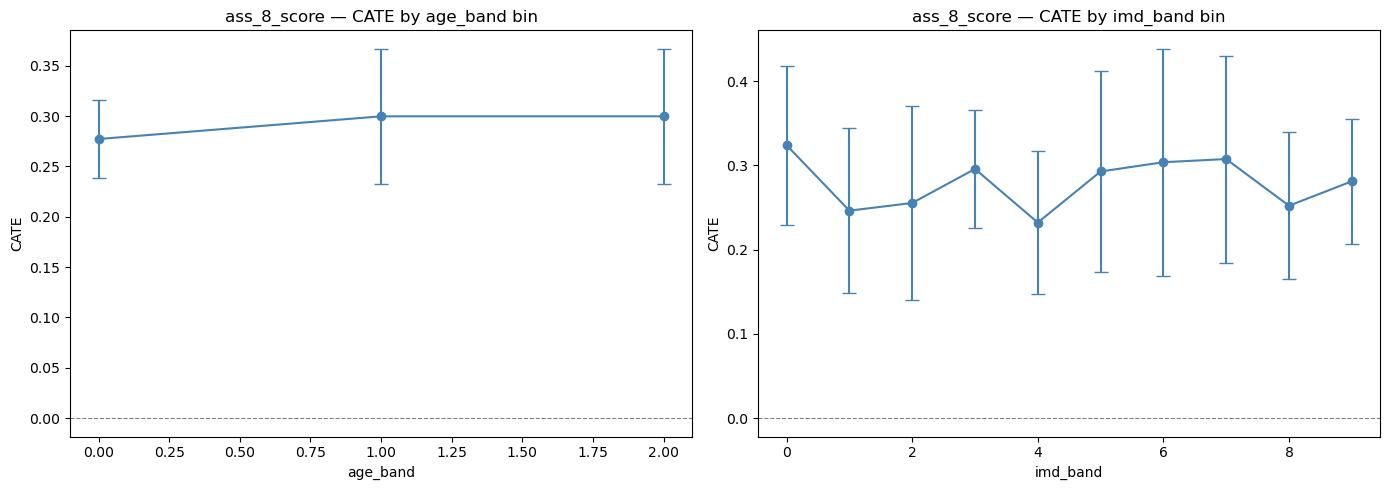

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_8_score.png


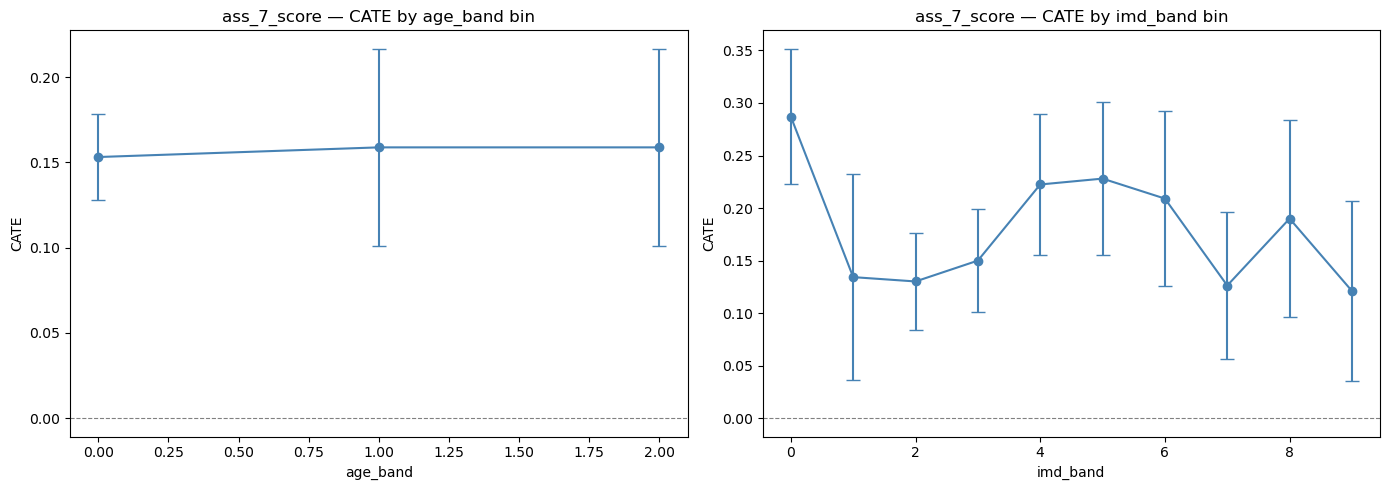

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_7_score.png


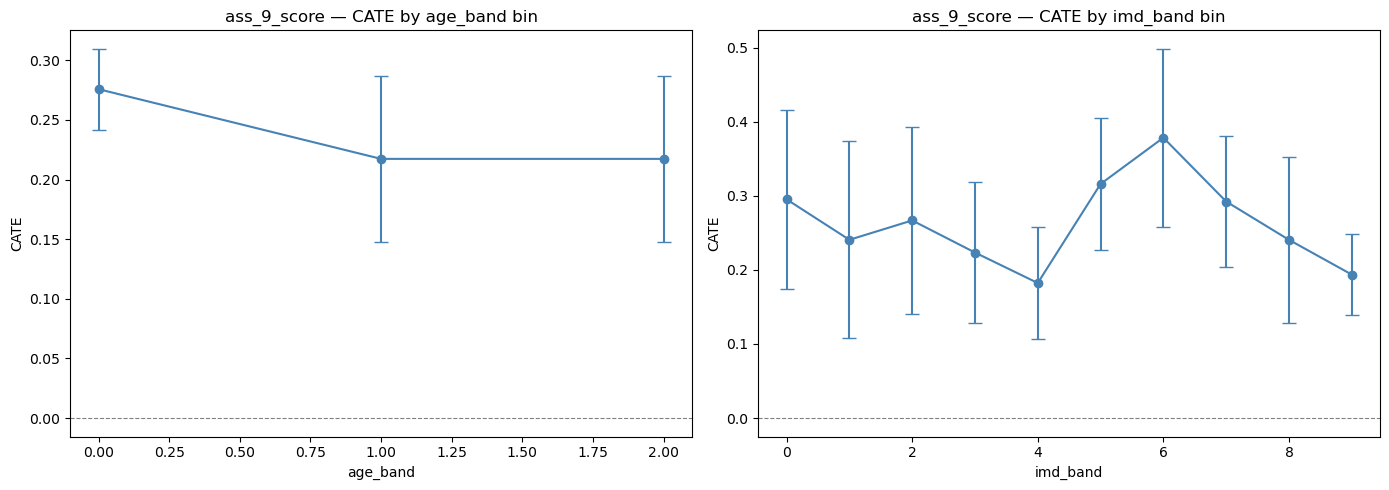

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_9_score.png


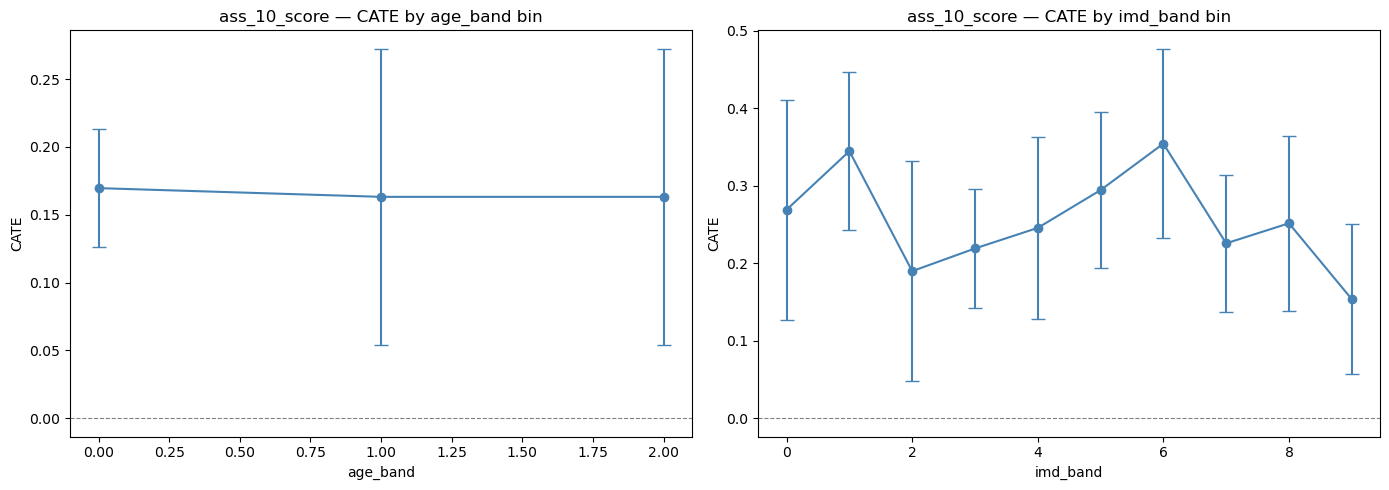

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_10_score.png


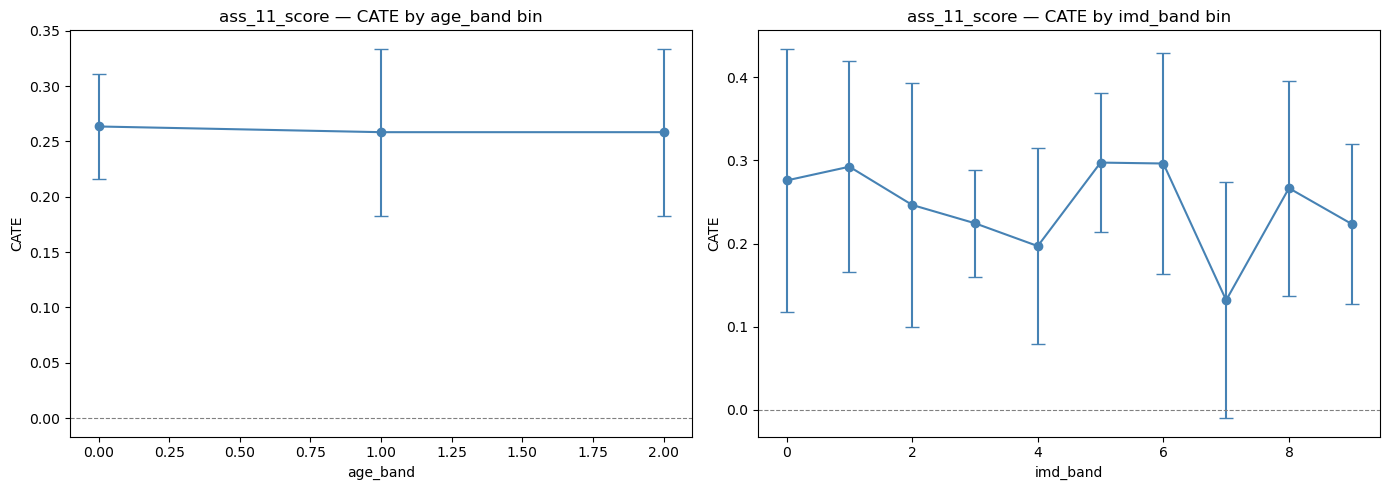

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_11_score.png


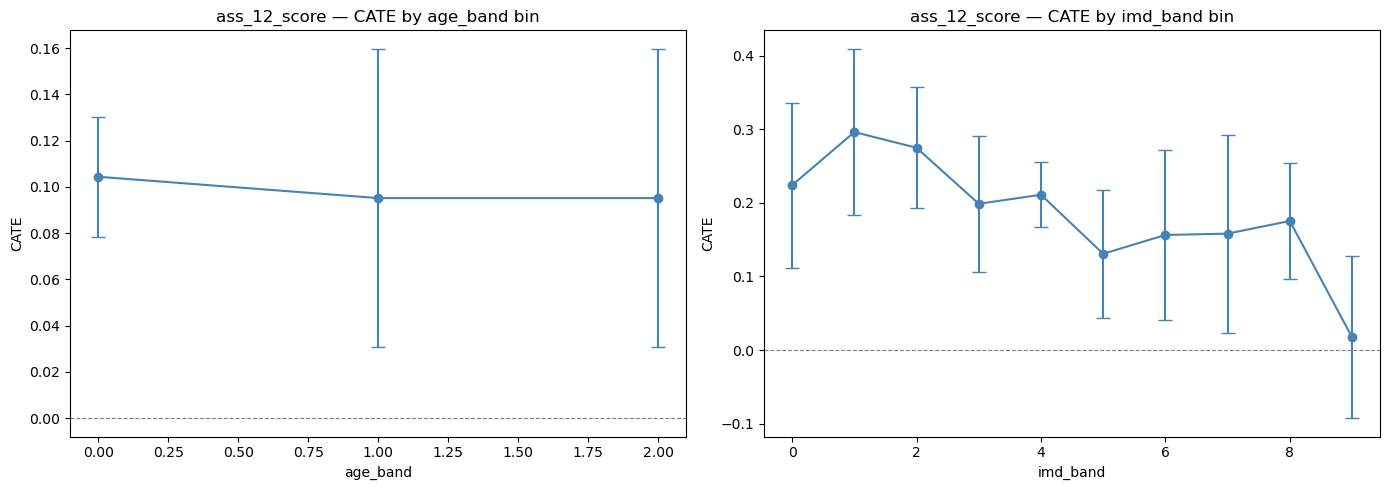

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATE_ass_12_score.png


In [31]:
# Block 9 — CATE point + CI plots

for treatment in treatments:
    adj_set = adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        if treatment == moderator:
            ax.axis('off')
            ax.set_title(f"{moderator} excluded (is treatment)")
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_model[[moderator]].values
        T = df_model[treatment].values
        Y = df_model['final_result'].values
        W = df_model[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_model[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"FFF_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## Policy tree — total_clicks only, both moderators, cost=0 (illustrative)

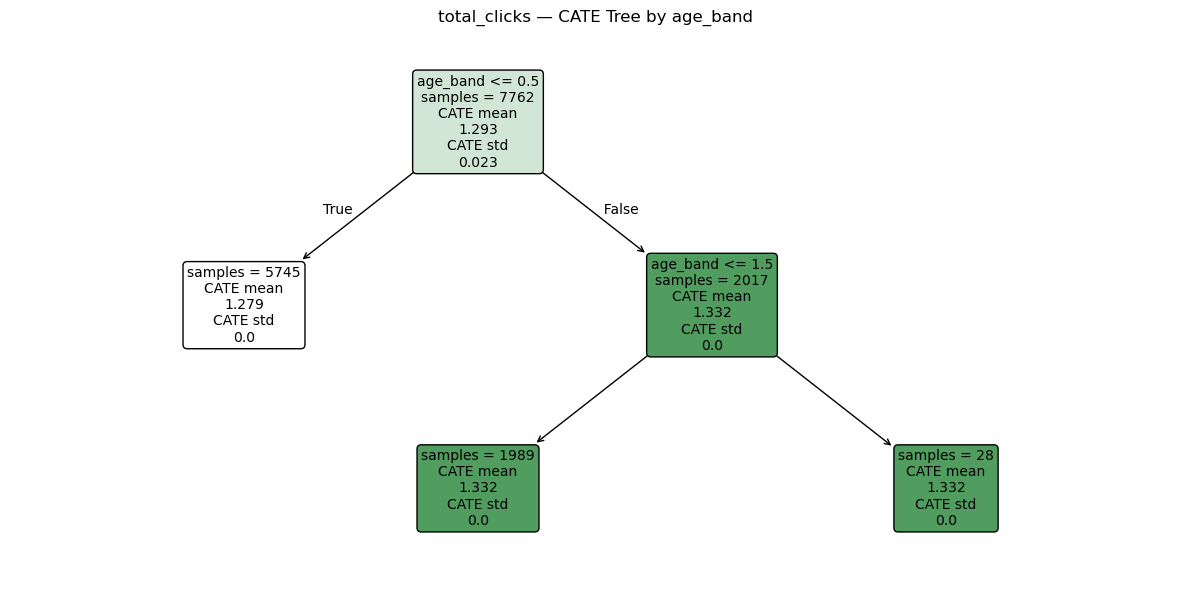

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATEtree_total_clicks_age_band.png


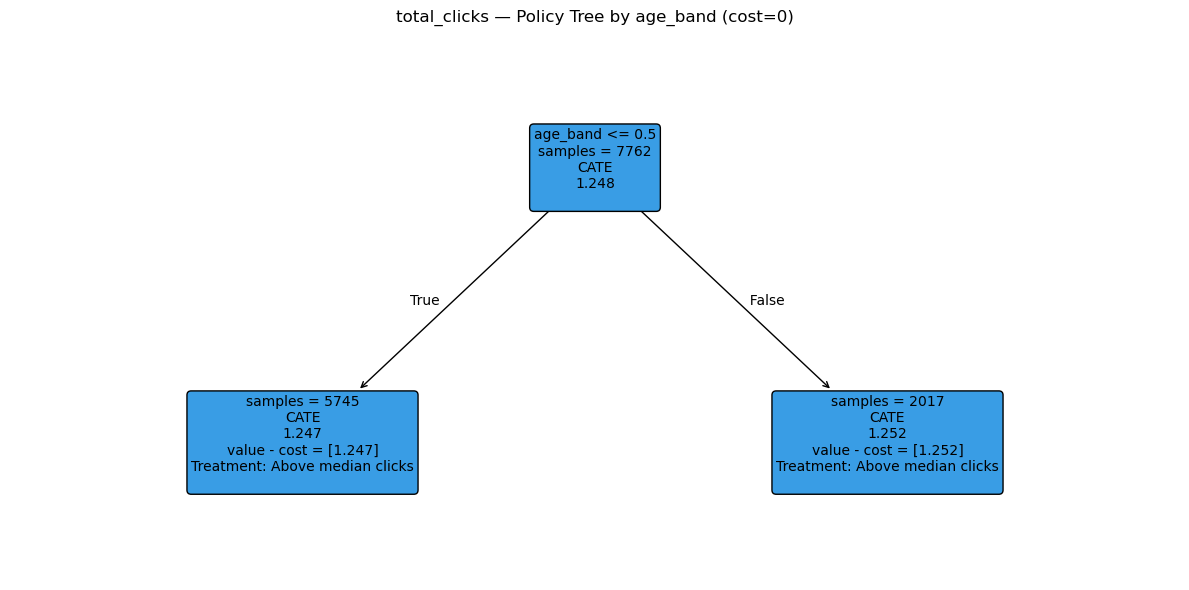

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_policytree_total_clicks_age_band.png


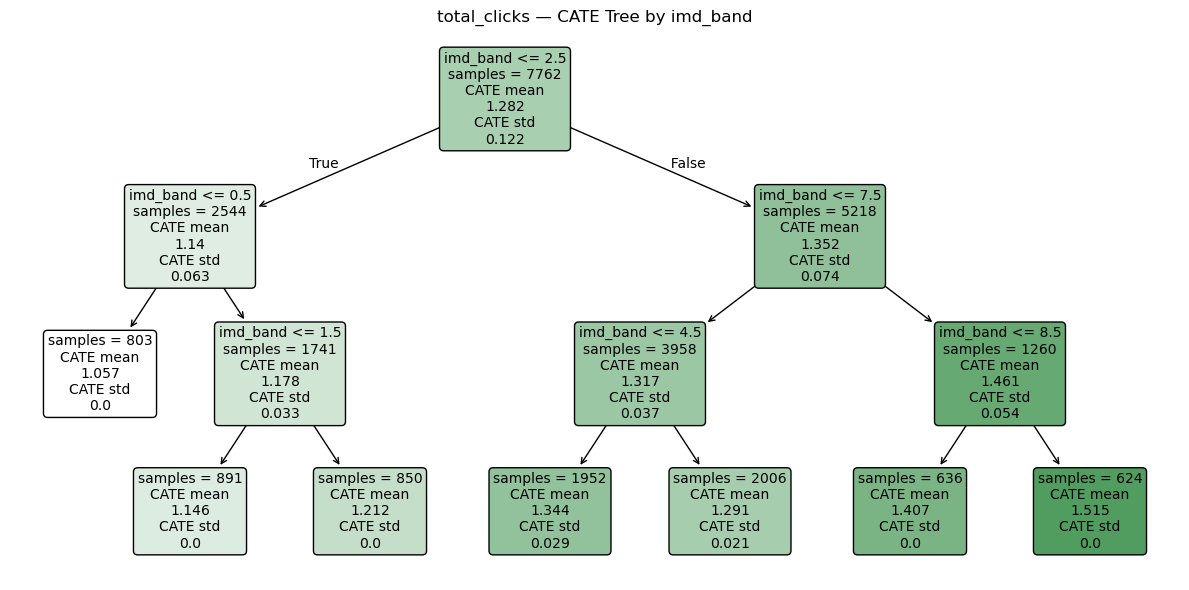

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_CATEtree_total_clicks_imd_band.png


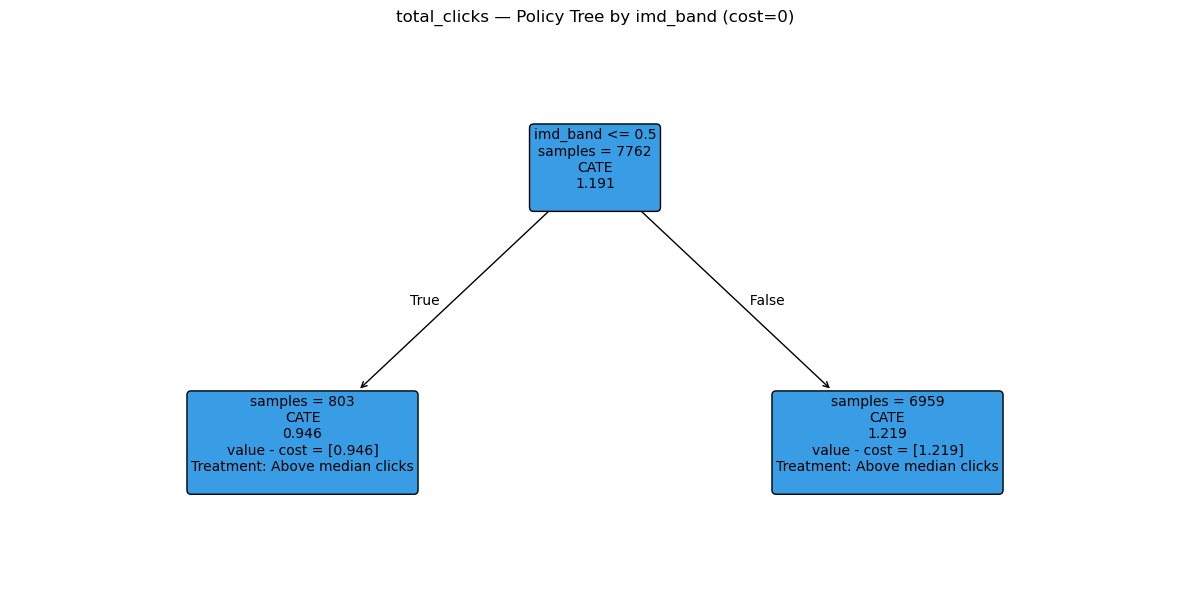

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_policytree_total_clicks_imd_band.png


In [34]:
# Block 10 — Policy tree restricted to total_clicks, both moderators, cost=0

from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

treatment = 'total_clicks'
adj_set = adjustment_sets[treatment]

for moderator in moderators:
    W_cols = [c for c in adj_set if c != moderator]

    X = df_model[[moderator]].values
    T_binary = (df_model[treatment] >= df_model[treatment].median()).astype(int).values
    Y = df_model['final_result'].values
    W = df_model[W_cols].values if len(W_cols) > 0 else None

    est = CausalForestDML(random_state=42)
    est.fit(Y, T_binary, X=X, W=W)

    cate_interpreter = SingleTreeCateInterpreter(include_model_uncertainty=False, max_depth=3)
    cate_interpreter.interpret(est, X)

    plt.figure(figsize=(12, 6))
    cate_interpreter.plot(feature_names=[moderator], fontsize=10)
    plt.title(f'total_clicks — CATE Tree by {moderator}')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"FFF_CATEtree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

    policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=30)
    policy_interpreter.interpret(est, X, sample_treatment_costs=0)

    plt.figure(figsize=(12, 6))
    policy_interpreter.plot(feature_names=[moderator], treatment_names=['Below median clicks', 'Above median clicks'], fontsize=10)
    plt.title(f'total_clicks — Policy Tree by {moderator} (cost=0)')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"FFF_policytree_total_clicks_{moderator}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## ATE heatmap

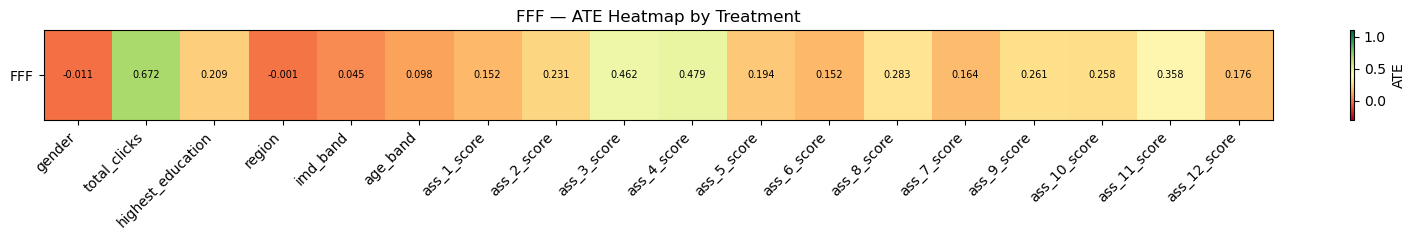

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_ATE_heatmap.png


In [37]:
# Block 11 — ATE heatmap, single row for FFF

heatmap_data = results_df.set_index('treatment')[['ATE']].T

plt.figure(figsize=(16, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=1.1)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
plt.yticks([0], ['FFF'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.3f}', ha='center', va='center', fontsize=7)

plt.title('FFF — ATE Heatmap by Treatment')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "FFF_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — manual fixed-position layout

WARNING — missing pos for: ['studied_credits', 'disability', 'num_of_prev_attempts']


KeyError: 'studied_credits'

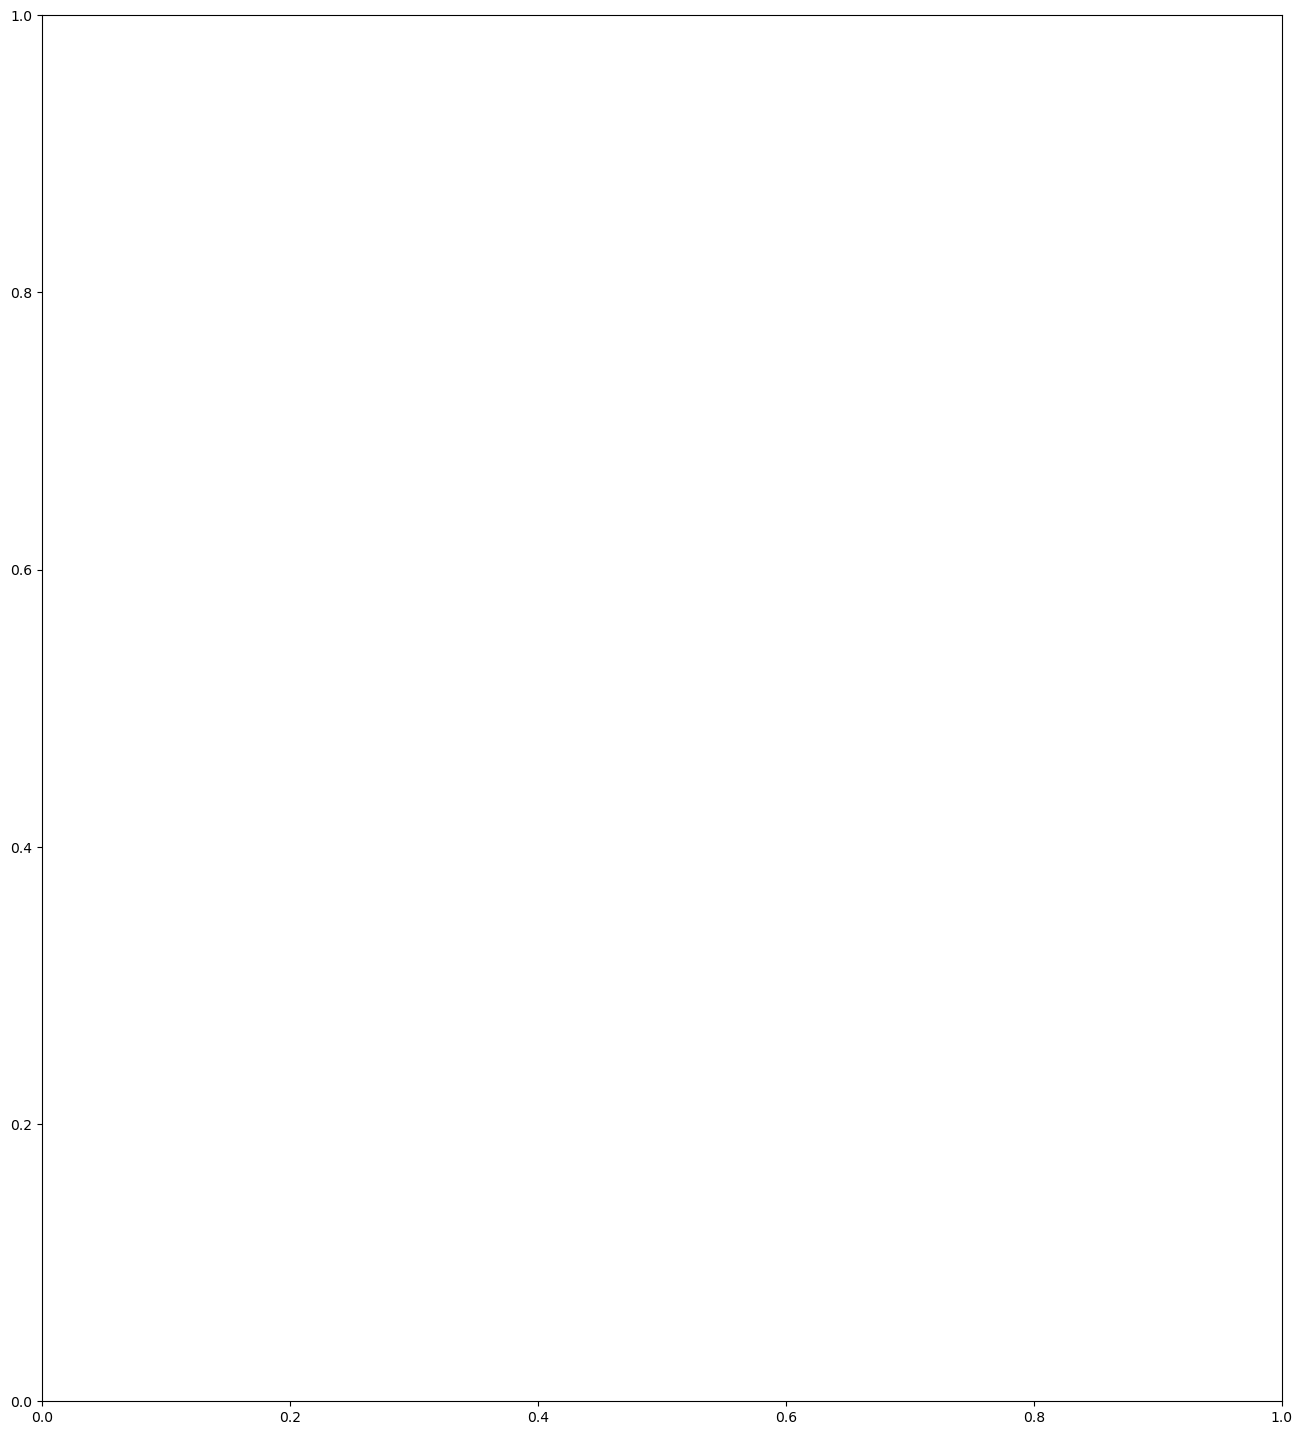

In [40]:
# Block 12 — DAG with ATE node overlay, manual fixed-position layout

pos = {
    # Demographic roots
    'gender': (0, 11),
    'imd_band': (3, 11),
    'age_band': (6, 11),

    'highest_education': (3, 9.7),
    'region': (5, 9.7),

    'total_clicks': (1, 9.7),

    # Assessment cascade (branching)
    'ass_1_score': (4, 8.3),
    'ass_2_score': (4, 7),
    'ass_3_score': (4, 5.7),
    'ass_4_score': (4, 4.4),
    'ass_5_score': (1.5, 3.1),
    'ass_6_score': (6.5, 3.1),
    'ass_7_score': (6.5, 1.8),
    'ass_8_score': (4, 1.8),
    'ass_9_score': (4, 0.5),
    'ass_10_score': (1.5, -0.8),
    'ass_11_score': (6.5, -0.8),
    'ass_12_score': (4, -2.1),

    'final_result': (4, -3.5),
}

ate_lookup = results_df.set_index('treatment')['ATE'].to_dict()

fig, ax = plt.subplots(figsize=(16, 18))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(700 + abs(ate_val) * 2500)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=10, alpha=0.4, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=1.1, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4))

cbar = plt.colorbar(nc, ax=ax, shrink=0.5)
cbar.set_label('ATE')

plt.title('FFF — Combined DAG with ATE Node Overlay')
plt.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "FFF_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## DAG with ATE node overlay — corrected with all node positions

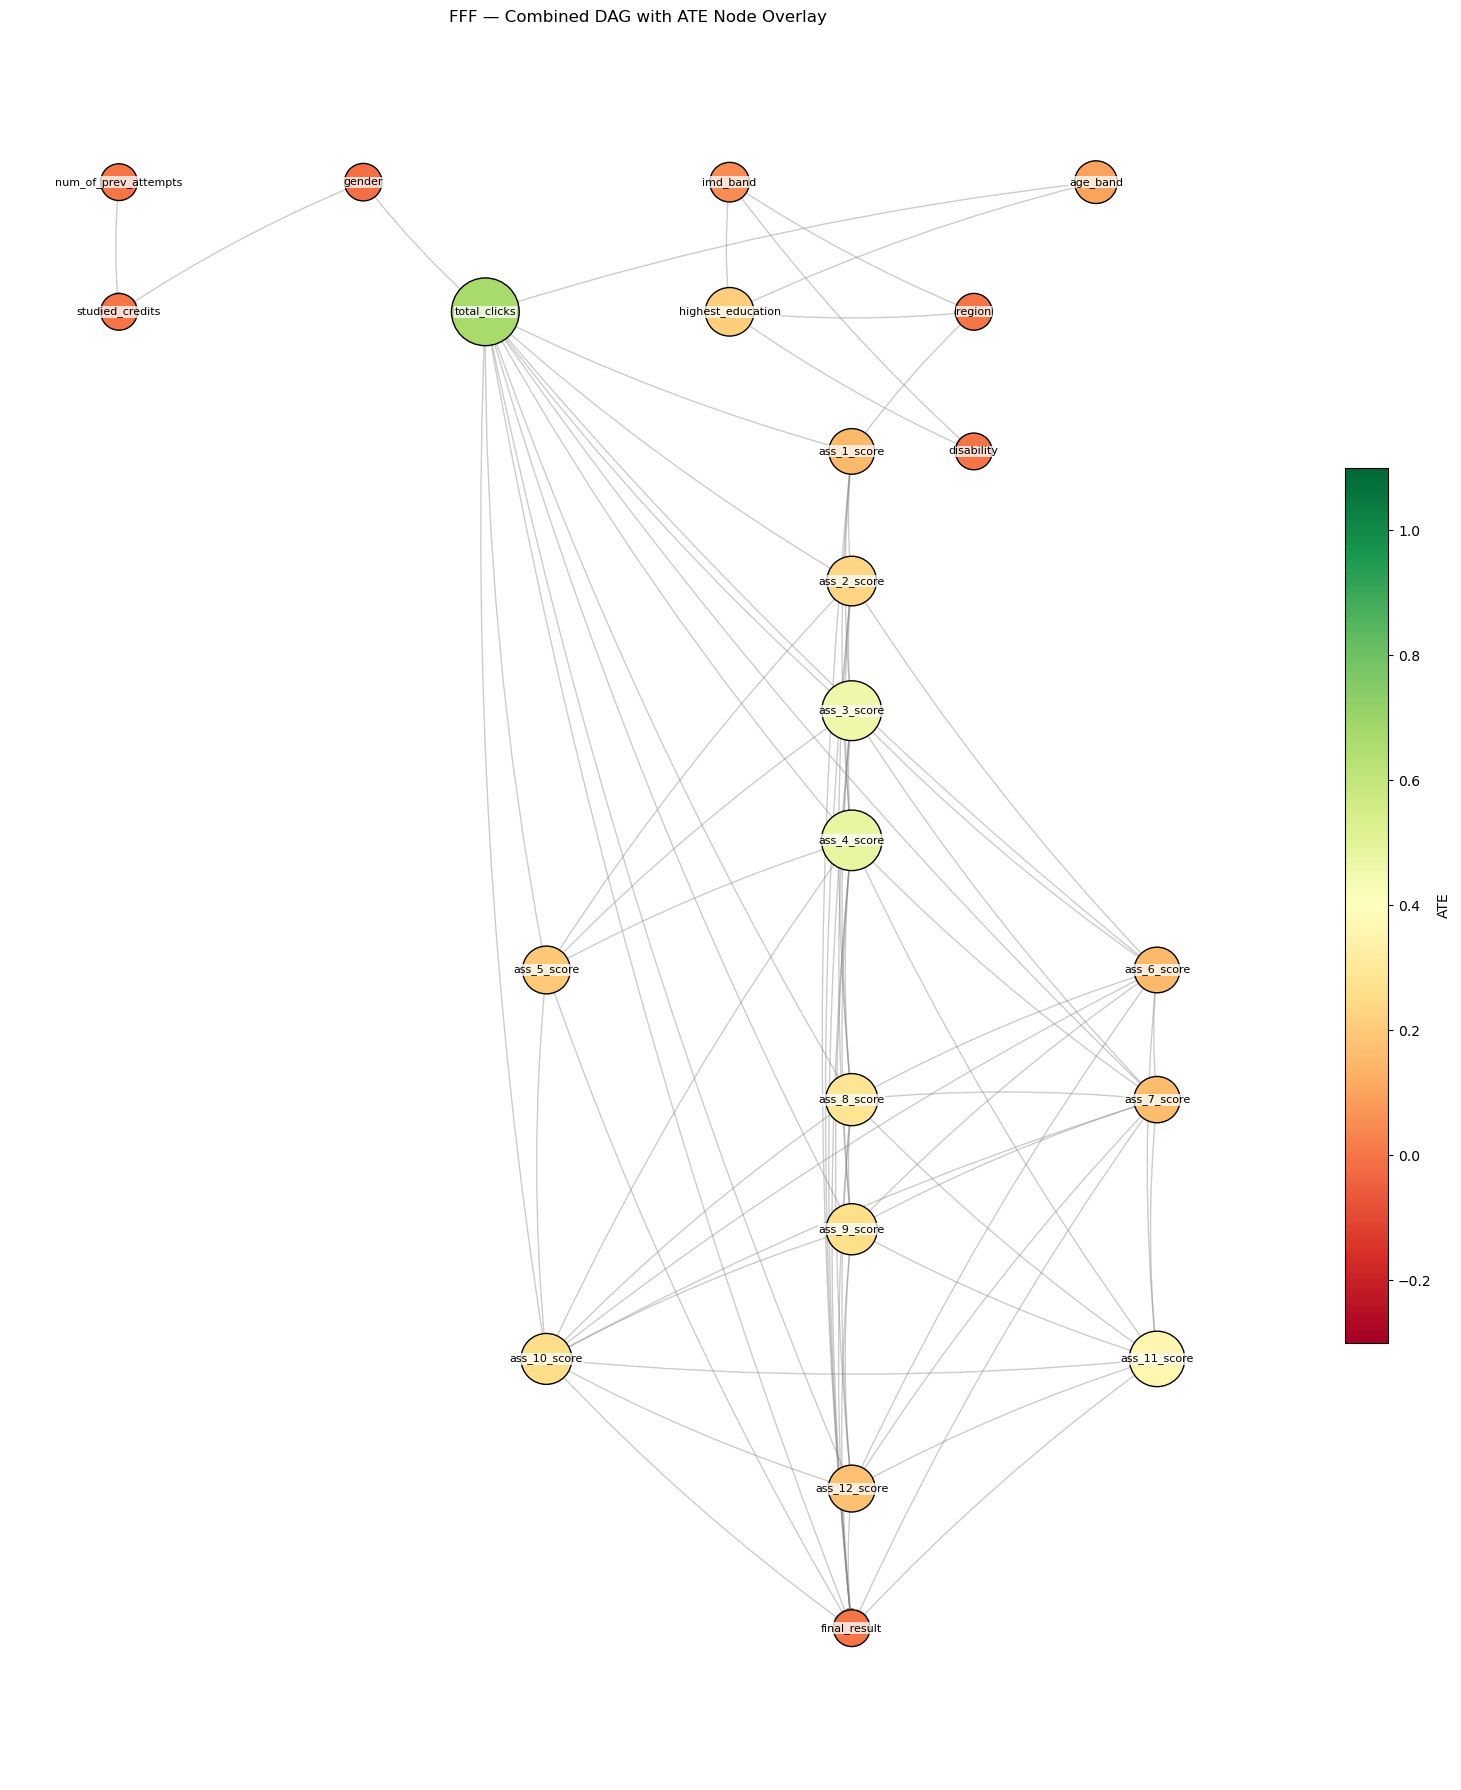

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\FFF\FFF_DAG_with_ATE.png


In [43]:
# Block 12 (corrected) — add missing positions for dead-end nodes

pos['studied_credits'] = (-2, 9.7)
pos['disability'] = (5, 8.3)
pos['num_of_prev_attempts'] = (-2, 11)

fig, ax = plt.subplots(figsize=(16, 18))

node_colors, node_sizes = [], []
for node in G.nodes():
    ate_val = ate_lookup.get(node, 0)
    node_colors.append(ate_val)
    node_sizes.append(700 + abs(ate_val) * 2500)

missing_pos = [n for n in G.nodes() if n not in pos]
if missing_pos:
    print("WARNING — missing pos for:", missing_pos)

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=10, alpha=0.4, connectionstyle='arc3,rad=0.05')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                             cmap='RdYlGn', vmin=-0.3, vmax=1.1, edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4))

cbar = plt.colorbar(nc, ax=ax, shrink=0.5)
cbar.set_label('ATE')

plt.title('FFF — Combined DAG with ATE Node Overlay')
plt.axis('off')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "FFF_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")